# Notebook 03 — Calibration

**Project:** Calibrated and Stability-Aware Explainable Intrusion Detection
**Author:** Md Anas Biswas, University of Portsmouth
**Stage:** 3 of 10

## Why calibration

A model can be 99% accurate yet poorly calibrated: when it says "97% confident", it might actually be right only 70% of the time. Calibration **aligns the model's stated confidence with empirical accuracy**, so a 97% confidence number means "97% of the time when I say this, I'm right".

Why this matters for your paper:
- SCTS-v2 (the trust score, Stage 7) consumes calibrated probabilities — uncalibrated input would corrupt the score.
- An analyst acting on alerts needs to trust that "high confidence" actually means high confidence.
- Calibration on imbalanced data is hard, and very few X-IDS papers attempt it. This is a real contribution.

## What this notebook does

For each of the 6 canonical models (3 architectures × 2 targets):

1. Compute **baseline ECE** (current miscalibration) on the test set
2. Hold out 20% of training data as the calibration set
3. Fit **temperature scaling** — per-class and global
4. Fit **isotonic regression** — per-class and global
5. Compare all 4 calibration variants on the test set using ECE, MCE, Brier score, NLL
6. Pick winner per model, save the calibrated probability arrays
7. Generate reliability diagrams for the paper

**Canonical 6 models:**
- `rf_binary_cw`, `xgb_binary_cw`, `dnn_binary_cw` — binary, class-weighted
- `rf_5class_smote`, `xgb_5class_smote`, `dnn_5class_smote` — 5-class, SMOTE (winners from Notebook 02b)

## Output files

```
calibrators/nsl_kdd/
├── rf_binary_cw_temp_perclass.pkl       # temperature scaling, per-class
├── rf_binary_cw_temp_global.pkl
├── rf_binary_cw_iso_perclass.pkl        # isotonic regression, per-class
├── rf_binary_cw_iso_global.pkl
├── ... (24 total: 6 models × 4 variants)
├── calibrated_probabilities/
│   ├── rf_binary_cw_calibrated.npy      # winning variant per model
│   └── ...
└── calibration_metrics.json             # ECE, MCE, Brier, NLL for all combinations
```

---
## Session start

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

# Restore git config + credentials from Drive
for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    dst = f'/root/{f}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        if f == '.git-credentials':
            os.chmod(dst, 0o600)

!git pull
print(f'\n✓ Ready in: {os.getcwd()}')

Mounted at /content/drive
Already up to date.

✓ Ready in: /content/drive/MyDrive/XIDS_Research/xids-research


In [2]:
# Imports
import numpy as np
import pandas as pd
import json, pickle, time
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [3]:
# Paths
PROCESSED = Path(REPO) / 'data' / 'processed' / 'nsl_kdd'
MODELS_DIR = Path(REPO) / 'models' / 'nsl_kdd'
PREDS_DIR = MODELS_DIR / 'predictions'
CALIB_DIR = Path(REPO) / 'calibrators' / 'nsl_kdd'
CALIB_PROBS_DIR = CALIB_DIR / 'calibrated_probabilities'
FIG_DIR = Path(REPO) / 'results' / 'figures'
TABLES_DIR = Path(REPO) / 'results' / 'tables'
for d in [CALIB_DIR, CALIB_PROBS_DIR, FIG_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Load data
X_train = np.load(PROCESSED / 'X_train.npy')
X_test  = np.load(PROCESSED / 'X_test.npy')
y_train_b = np.load(PROCESSED / 'y_train_binary.npy')
y_test_b  = np.load(PROCESSED / 'y_test_binary.npy')
y_train_5 = np.load(PROCESSED / 'y_train_5class.npy')
y_test_5  = np.load(PROCESSED / 'y_test_5class.npy')

with open(PROCESSED / 'class_mappings.json') as f:
    class_info = json.load(f)
INT_TO_CATEGORY = {int(k): v for k, v in class_info['multiclass_5'].items()}
CLASS_NAMES_BINARY = ['Normal', 'Attack']
CLASS_NAMES_5 = [INT_TO_CATEGORY[i] for i in range(5)]

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Train binary: {np.bincount(y_train_b)}')
print(f'Train 5-class: {np.bincount(y_train_5)}')

X_train: (125973, 122), X_test: (22544, 122)
Train binary: [67343 58630]
Train 5-class: [67343 45927 11656   995    52]


---
## Step 1 — Split off the calibration set

Take 20% of training data as the calibration set, **stratified by class** so rare classes are represented.

We use the same 80/20 split for both binary and 5-class so the calibration data is consistent across targets.

In [4]:
# Stratify by 5-class labels (more granular) so all 5 classes appear in both folds
idx_train_only, idx_calib = train_test_split(
    np.arange(len(X_train)),
    test_size=0.20,
    stratify=y_train_5,
    random_state=SEED,
)

X_calib = X_train[idx_calib]
y_calib_b = y_train_b[idx_calib]
y_calib_5 = y_train_5[idx_calib]

print(f'Calibration set: {X_calib.shape[0]:,} rows ({len(idx_calib)/len(X_train)*100:.1f}% of training)')
print(f'\nCalibration set — binary distribution:')
for i in range(2):
    print(f'  {CLASS_NAMES_BINARY[i]}: {np.sum(y_calib_b == i):,}')
print(f'\nCalibration set — 5-class distribution:')
for i in range(5):
    print(f'  {CLASS_NAMES_5[i]:8s}: {np.sum(y_calib_5 == i):,}')

Calibration set: 25,195 rows (20.0% of training)

Calibration set — binary distribution:
  Normal: 13,469
  Attack: 11,726

Calibration set — 5-class distribution:
  Normal  : 13,469
  DoS     : 9,186
  Probe   : 2,331
  R2L     : 199
  U2R     : 10


---
## Step 2 — Load the canonical models and get their calibration-set predictions

For each canonical model, we need predict_proba on:
- The **calibration set** (to fit calibrators)
- The **test set** (to evaluate calibration quality)

Test-set predictions are already saved from Notebook 02. We just need to compute calibration-set predictions now.

In [5]:
# Re-load DNN models — they need the architecture spec
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(256, 128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def load_model(name):
    '''Load a model from models/nsl_kdd/{name}.pkl or .pt'''
    pkl_path = MODELS_DIR / f'{name}.pkl'
    pt_path  = MODELS_DIR / f'{name}.pt'
    if pkl_path.exists():
        with open(pkl_path, 'rb') as f:
            return ('sklearn', pickle.load(f))
    elif pt_path.exists():
        state = torch.load(pt_path, map_location=DEVICE, weights_only=False)
        model = MLP(state['in_dim'], state['n_classes'],
                    hidden=tuple(state['hidden']), dropout=state['dropout']).to(DEVICE)
        model.load_state_dict(state['state_dict'])
        model.eval()
        return ('torch', model)
    else:
        raise FileNotFoundError(f'No model file for {name}')

def predict_proba(model_tuple, X):
    '''Get predict_proba for either type.'''
    kind, model = model_tuple
    if kind == 'sklearn':
        return model.predict_proba(X)
    else:
        with torch.no_grad():
            X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
            logits = model(X_t)
            return torch.softmax(logits, dim=1).cpu().numpy()

def get_logits(model_tuple, X):
    '''Get pre-softmax logits (needed for temperature scaling).'''
    kind, model = model_tuple
    if kind == 'torch':
        with torch.no_grad():
            X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
            return model(X_t).cpu().numpy()
    else:
        # For sklearn models, use log-probabilities as pseudo-logits
        # (log(p) is what softmax inverts to up to a constant)
        proba = model.predict_proba(X)
        # Avoid log(0)
        proba = np.clip(proba, 1e-12, 1 - 1e-12)
        return np.log(proba)

# Canonical 6 models
CANONICAL = {
    'rf_binary_cw':      {'target': 'binary'},
    'xgb_binary_cw':     {'target': 'binary'},
    'dnn_binary_cw':     {'target': 'binary'},
    'rf_5class_smote':   {'target': '5class'},
    'xgb_5class_smote':  {'target': '5class'},
    'dnn_5class_smote':  {'target': '5class'},
}

print('Loading models and computing calibration-set predictions...\n')
PREDS = {}  # name → {'proba_calib': ..., 'proba_test': ..., 'logits_calib': ..., 'logits_test': ...}
for name in CANONICAL:
    t0 = time.time()
    model = load_model(name)
    proba_calib = predict_proba(model, X_calib)
    proba_test = predict_proba(model, X_test)
    logits_calib = get_logits(model, X_calib)
    logits_test = get_logits(model, X_test)
    PREDS[name] = {
        'proba_calib': proba_calib,
        'proba_test': proba_test,
        'logits_calib': logits_calib,
        'logits_test': logits_test,
    }
    print(f'  ✓ {name:25s}  ({time.time()-t0:.1f}s)  proba_test shape={proba_test.shape}')

Loading models and computing calibration-set predictions...

  ✓ rf_binary_cw               (3.1s)  proba_test shape=(22544, 2)
  ✓ xgb_binary_cw              (1.4s)  proba_test shape=(22544, 2)
  ✓ dnn_binary_cw              (1.2s)  proba_test shape=(22544, 2)
  ✓ rf_5class_smote            (3.0s)  proba_test shape=(22544, 5)
  ✓ xgb_5class_smote           (5.8s)  proba_test shape=(22544, 5)
  ✓ dnn_5class_smote           (1.0s)  proba_test shape=(22544, 5)


---
## Step 3 — Calibration metrics

**Expected Calibration Error (ECE)** — bins predictions by confidence, measures gap between confidence and accuracy.
$$ECE = \sum_{m=1}^M \frac{|B_m|}{n} | \text{acc}(B_m) - \text{conf}(B_m) |$$

**Maximum Calibration Error (MCE)** — same but max instead of weighted sum, captures worst-bin error.

**Brier score** — squared error between predicted probability and one-hot label. Lower is better.

**NLL (negative log likelihood)** — standard probabilistic loss. Lower is better. Sensitive to under-confidence.

In [6]:
def expected_calibration_error(y_true, y_proba, n_bins=15):
    '''Multi-class ECE — uses predicted-class confidence.'''
    confidences = y_proba.max(axis=1)
    predictions = y_proba.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    mce = 0.0
    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (confidences > lo) & (confidences <= hi)
        if i == 0:
            in_bin = in_bin | (confidences == lo)
        prop = in_bin.mean()
        if prop > 0:
            bin_acc = accuracies[in_bin].mean()
            bin_conf = confidences[in_bin].mean()
            gap = abs(bin_acc - bin_conf)
            ece += prop * gap
            mce = max(mce, gap)
    return float(ece), float(mce)

def brier_multiclass(y_true, y_proba):
    '''Multi-class Brier score (mean squared error between one-hot label and predicted probs).'''
    n_classes = y_proba.shape[1]
    onehot = np.eye(n_classes)[y_true]
    return float(np.mean(np.sum((y_proba - onehot) ** 2, axis=1)))

def all_calibration_metrics(y_true, y_proba, name=''):
    '''Compute ECE, MCE, Brier, NLL, plus accuracy and macro F1.'''
    ece, mce = expected_calibration_error(y_true, y_proba)
    # Avoid log(0) for NLL
    y_proba_clipped = np.clip(y_proba, 1e-12, 1 - 1e-12)
    nll = log_loss(y_true, y_proba_clipped, labels=np.arange(y_proba.shape[1]))
    brier = brier_multiclass(y_true, y_proba)
    y_pred = y_proba.argmax(axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {
        'ece': ece, 'mce': mce, 'brier': brier, 'nll': float(nll),
        'accuracy': acc, 'f1_macro': f1m,
    }

# Baseline (uncalibrated) metrics for all 6 models
print('Baseline (uncalibrated) calibration metrics on test set:\n')
print(f'{"Model":<22} {"ECE":>7} {"MCE":>7} {"Brier":>7} {"NLL":>7}  {"Acc":>6} {"F1m":>6}')
print('-' * 75)
BASELINE = {}
for name, info in CANONICAL.items():
    y_true = y_test_b if info['target'] == 'binary' else y_test_5
    proba = PREDS[name]['proba_test']
    m = all_calibration_metrics(y_true, proba)
    BASELINE[name] = m
    print(f'{name:<22} {m["ece"]:>7.4f} {m["mce"]:>7.4f} {m["brier"]:>7.4f} {m["nll"]:>7.4f}  {m["accuracy"]:>6.4f} {m["f1_macro"]:>6.4f}')

Baseline (uncalibrated) calibration metrics on test set:

Model                      ECE     MCE   Brier     NLL     Acc    F1m
---------------------------------------------------------------------------
rf_binary_cw            0.1668  0.6298  0.3310  0.7339  0.7649 0.7636
xgb_binary_cw           0.1905  0.3542  0.3899  1.2251  0.7936 0.7932
dnn_binary_cw           0.1909  0.6065  0.3829  1.6309  0.7905 0.7904
rf_5class_smote         0.1632  0.6620  0.3624  1.5033  0.7483 0.5253
xgb_5class_smote        0.1847  0.4423  0.3903  1.7672  0.7943 0.6387
dnn_5class_smote        0.2013  0.4243  0.4122  2.5218  0.7886 0.5839


---
## Step 4 — Temperature scaling

Find a single temperature parameter T such that the softened probabilities $\text{softmax}(z/T)$ minimise NLL on the calibration set. T > 1 makes the model less confident; T < 1 sharpens.

**Global temperature**: one T for all classes.
**Per-class temperature**: one T per class. More expressive, can help with class-conditional miscalibration.

We use scipy's L-BFGS-B for optimisation.

In [7]:
from scipy.optimize import minimize

def softmax_with_T(logits, T):
    '''Softmax with temperature. T can be scalar or per-class vector.'''
    z = logits / T
    # Numeric stability
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def nll_loss(probs, y_true):
    '''Mean negative log likelihood.'''
    probs = np.clip(probs, 1e-12, 1 - 1e-12)
    return -np.mean(np.log(probs[np.arange(len(y_true)), y_true]))

def fit_temperature_global(logits_calib, y_calib):
    '''Fit a single scalar T.'''
    def loss(T_arr):
        T = T_arr[0]
        if T <= 0:
            return 1e10
        probs = softmax_with_T(logits_calib, T)
        return nll_loss(probs, y_calib)
    res = minimize(loss, x0=[1.0], method='L-BFGS-B', bounds=[(0.05, 10.0)])
    return float(res.x[0])

def fit_temperature_per_class(logits_calib, y_calib):
    '''Fit one T per class.'''
    n_classes = logits_calib.shape[1]
    def loss(T_arr):
        if np.any(T_arr <= 0):
            return 1e10
        # Apply per-class temperature: divide column j by T_arr[j]
        z = logits_calib / T_arr[None, :]
        z = z - z.max(axis=1, keepdims=True)
        e = np.exp(z)
        probs = e / e.sum(axis=1, keepdims=True)
        return nll_loss(probs, y_calib)
    x0 = np.ones(n_classes)
    bounds = [(0.05, 10.0)] * n_classes
    res = minimize(loss, x0=x0, method='L-BFGS-B', bounds=bounds)
    return res.x  # vector of length n_classes

def apply_temperature(logits, T):
    '''T is scalar (global) or vector (per-class).'''
    if np.ndim(T) == 0:
        return softmax_with_T(logits, T)
    else:
        z = logits / np.asarray(T)[None, :]
        z = z - z.max(axis=1, keepdims=True)
        e = np.exp(z)
        return e / e.sum(axis=1, keepdims=True)

# Fit and evaluate temperature scaling for all 6 models
print('Fitting temperature scaling on calibration set...\n')
TEMP_PARAMS = {}  # name → {'global': T, 'per_class': T_vec}
TEMP_METRICS = {}  # name → {'global': metrics, 'per_class': metrics}
for name, info in CANONICAL.items():
    y_calib = y_calib_b if info['target'] == 'binary' else y_calib_5
    y_test = y_test_b if info['target'] == 'binary' else y_test_5
    logits_c = PREDS[name]['logits_calib']
    logits_t = PREDS[name]['logits_test']

    T_global = fit_temperature_global(logits_c, y_calib)
    T_perclass = fit_temperature_per_class(logits_c, y_calib)
    TEMP_PARAMS[name] = {'global': T_global, 'per_class': T_perclass}

    # Evaluate on test
    proba_test_g = apply_temperature(logits_t, T_global)
    proba_test_p = apply_temperature(logits_t, T_perclass)
    TEMP_METRICS[name] = {
        'global': all_calibration_metrics(y_test, proba_test_g),
        'per_class': all_calibration_metrics(y_test, proba_test_p),
    }
    # Store calibrated test predictions
    PREDS[name]['proba_test_temp_global'] = proba_test_g
    PREDS[name]['proba_test_temp_perclass'] = proba_test_p

    print(f'  {name:<22}  T_global={T_global:.3f}  T_perclass={T_perclass.round(3).tolist()}')

Fitting temperature scaling on calibration set...

  rf_binary_cw            T_global=0.050  T_perclass=[0.05, 0.057]
  xgb_binary_cw           T_global=0.050  T_perclass=[0.05, 0.078]
  dnn_binary_cw           T_global=0.728  T_perclass=[0.355, 10.0]
  rf_5class_smote         T_global=0.050  T_perclass=[0.062, 0.155, 0.05, 0.051, 0.05]
  xgb_5class_smote        T_global=0.050  T_perclass=[0.058, 0.347, 0.05, 0.103, 0.05]
  dnn_5class_smote        T_global=1.592  T_perclass=[0.576, 1.07, 1.095, 2.106, 8.029]


---
## Step 5 — Isotonic regression

Isotonic regression fits a non-parametric monotonic mapping from predicted probabilities to corrected ones. More flexible than temperature scaling (which only scales). For multi-class, we fit one regressor per class in a **one-vs-rest** style.

**Per-class**: a separate isotonic regressor for each class's probability column.
**Global**: a single regressor on the max-confidence (one-vs-all of the predicted class). Less common, included for completeness.

In [8]:
def fit_isotonic_per_class(proba_calib, y_calib):
    '''Fit one IsotonicRegression per class (one-vs-rest).'''
    n_classes = proba_calib.shape[1]
    regressors = []
    for c in range(n_classes):
        ir = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
        y_c = (y_calib == c).astype(float)
        ir.fit(proba_calib[:, c], y_c)
        regressors.append(ir)
    return regressors

def apply_isotonic_per_class(proba, regressors):
    '''Apply per-class regressors and re-normalise so rows sum to 1.'''
    n_classes = proba.shape[1]
    out = np.zeros_like(proba)
    for c in range(n_classes):
        out[:, c] = regressors[c].predict(proba[:, c])
    # Re-normalise rows
    out = np.clip(out, 1e-12, None)
    out = out / out.sum(axis=1, keepdims=True)
    return out

def fit_isotonic_global(proba_calib, y_calib):
    '''Fit a single regressor on (max-confidence, was-correct) pairs.'''
    confidence = proba_calib.max(axis=1)
    pred = proba_calib.argmax(axis=1)
    correct = (pred == y_calib).astype(float)
    ir = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
    ir.fit(confidence, correct)
    return ir

def apply_isotonic_global(proba, regressor):
    '''Rescale the predicted-class probability with the regressor; redistribute the rest.'''
    n_classes = proba.shape[1]
    pred = proba.argmax(axis=1)
    conf = proba.max(axis=1)
    new_conf = regressor.predict(conf)
    new_conf = np.clip(new_conf, 1e-12, 1 - 1e-12)
    out = proba.copy()
    for i in range(len(out)):
        c = pred[i]
        old_conf = conf[i]
        # Set predicted class to new_conf, scale others proportionally
        rest_total = 1.0 - old_conf
        if rest_total > 0:
            scale = (1.0 - new_conf[i]) / rest_total
            out[i] = out[i] * scale
        else:
            out[i] = (1.0 - new_conf[i]) / (n_classes - 1)
        out[i, c] = new_conf[i]
        # Renormalise just in case
        out[i] = out[i] / out[i].sum()
    return out

# Fit and evaluate isotonic for all 6 models
print('Fitting isotonic regression on calibration set...\n')
ISO_REGRESSORS = {}
ISO_METRICS = {}
for name, info in CANONICAL.items():
    y_calib = y_calib_b if info['target'] == 'binary' else y_calib_5
    y_test = y_test_b if info['target'] == 'binary' else y_test_5
    proba_c = PREDS[name]['proba_calib']
    proba_t = PREDS[name]['proba_test']

    iso_pc = fit_isotonic_per_class(proba_c, y_calib)
    iso_g = fit_isotonic_global(proba_c, y_calib)
    ISO_REGRESSORS[name] = {'per_class': iso_pc, 'global': iso_g}

    proba_test_pc = apply_isotonic_per_class(proba_t, iso_pc)
    proba_test_g = apply_isotonic_global(proba_t, iso_g)
    ISO_METRICS[name] = {
        'per_class': all_calibration_metrics(y_test, proba_test_pc),
        'global': all_calibration_metrics(y_test, proba_test_g),
    }
    PREDS[name]['proba_test_iso_perclass'] = proba_test_pc
    PREDS[name]['proba_test_iso_global'] = proba_test_g

    print(f'  ✓ {name}')

Fitting isotonic regression on calibration set...

  ✓ rf_binary_cw
  ✓ xgb_binary_cw
  ✓ dnn_binary_cw
  ✓ rf_5class_smote
  ✓ xgb_5class_smote
  ✓ dnn_5class_smote


---
## Step 6 — Full comparison table

Five rows per model: uncalibrated, temp-global, temp-perclass, iso-global, iso-perclass.

In [9]:
rows = []
for name in CANONICAL:
    for variant, m in [
        ('uncalibrated',  BASELINE[name]),
        ('temp_global',   TEMP_METRICS[name]['global']),
        ('temp_perclass', TEMP_METRICS[name]['per_class']),
        ('iso_global',    ISO_METRICS[name]['global']),
        ('iso_perclass',  ISO_METRICS[name]['per_class']),
    ]:
        rows.append({
            'Model': name,
            'Variant': variant,
            'ECE': m['ece'],
            'MCE': m['mce'],
            'Brier': m['brier'],
            'NLL': m['nll'],
            'Accuracy': m['accuracy'],
            'F1m': m['f1_macro'],
        })

df_calib = pd.DataFrame(rows)
print('CALIBRATION COMPARISON (lower ECE/MCE/Brier/NLL is better)')
print('=' * 100)
print(df_calib.to_string(index=False, float_format='%.4f'))
print('=' * 100)

df_calib.to_csv(TABLES_DIR / 'nslkdd_calibration_comparison.csv', index=False)
print(f'\n✓ Saved to {TABLES_DIR / "nslkdd_calibration_comparison.csv"}')

CALIBRATION COMPARISON (lower ECE/MCE/Brier/NLL is better)
           Model       Variant    ECE    MCE  Brier    NLL  Accuracy    F1m
    rf_binary_cw  uncalibrated 0.1668 0.6298 0.3310 0.7339    0.7649 0.7636
    rf_binary_cw   temp_global 0.2295 0.5150 0.4590 5.0651    0.7649 0.7636
    rf_binary_cw temp_perclass 0.2225 0.5148 0.4435 4.8155    0.7736 0.7727
    rf_binary_cw    iso_global 0.2255 0.6139 0.4548 6.0782    0.7687 0.7676
    rf_binary_cw  iso_perclass 0.2238 0.8040 0.4484 6.0780    0.7737 0.7728
   xgb_binary_cw  uncalibrated 0.1905 0.3542 0.3899 1.2251    0.7936 0.7932
   xgb_binary_cw   temp_global 0.2061 0.7096 0.4122 3.2437    0.7936 0.7932
   xgb_binary_cw temp_perclass 0.2035 0.4751 0.4072 5.3883    0.7962 0.7958
   xgb_binary_cw    iso_global 0.2064 0.2064 0.4128 3.2905    0.7936 0.7932
   xgb_binary_cw  iso_perclass 0.2026 0.5032 0.4064 3.2083    0.7959 0.7956
   dnn_binary_cw  uncalibrated 0.1909 0.6065 0.3829 1.6309    0.7905 0.7904
   dnn_binary_cw   temp_globa

---
## Step 7 — Pick winner per model and save

In [10]:
# Winner = lowest ECE on test set (the standard calibration metric)
print('Per-model winner (by ECE):')
print(f'{"Model":<22} {"Best variant":<16} {"ECE":>7} {"vs uncalibrated":<20}')
print('-' * 70)
WINNERS = {}
for name in CANONICAL:
    options = {
        'uncalibrated':   BASELINE[name],
        'temp_global':    TEMP_METRICS[name]['global'],
        'temp_perclass':  TEMP_METRICS[name]['per_class'],
        'iso_global':     ISO_METRICS[name]['global'],
        'iso_perclass':   ISO_METRICS[name]['per_class'],
    }
    best_variant = min(options, key=lambda v: options[v]['ece'])
    best_ece = options[best_variant]['ece']
    baseline_ece = options['uncalibrated']['ece']
    delta = baseline_ece - best_ece
    WINNERS[name] = {
        'variant': best_variant,
        'ece': best_ece,
        'baseline_ece': baseline_ece,
        'reduction': delta,
    }
    print(f'{name:<22} {best_variant:<16} {best_ece:>7.4f}  ({delta:+.4f} from {baseline_ece:.4f})')

Per-model winner (by ECE):
Model                  Best variant         ECE vs uncalibrated     
----------------------------------------------------------------------
rf_binary_cw           uncalibrated      0.1668  (+0.0000 from 0.1668)
xgb_binary_cw          uncalibrated      0.1905  (+0.0000 from 0.1905)
dnn_binary_cw          uncalibrated      0.1909  (+0.0000 from 0.1909)
rf_5class_smote        uncalibrated      0.1632  (+0.0000 from 0.1632)
xgb_5class_smote       uncalibrated      0.1847  (+0.0000 from 0.1847)
dnn_5class_smote       iso_global        0.1912  (+0.0101 from 0.2013)


In [11]:
# Save winning calibrators and calibrated probability arrays
print('\nSaving artifacts...\n')

# Save all calibrators (full set, not just winners — needed for paper transparency)
for name in CANONICAL:
    # Temperature scaling parameters
    with open(CALIB_DIR / f'{name}_temp_global.pkl', 'wb') as f:
        pickle.dump(TEMP_PARAMS[name]['global'], f)
    with open(CALIB_DIR / f'{name}_temp_perclass.pkl', 'wb') as f:
        pickle.dump(TEMP_PARAMS[name]['per_class'], f)
    # Isotonic regressors
    with open(CALIB_DIR / f'{name}_iso_perclass.pkl', 'wb') as f:
        pickle.dump(ISO_REGRESSORS[name]['per_class'], f)
    with open(CALIB_DIR / f'{name}_iso_global.pkl', 'wb') as f:
        pickle.dump(ISO_REGRESSORS[name]['global'], f)

# Save winning calibrated probabilities (these are what later notebooks consume)
for name, w in WINNERS.items():
    variant = w['variant']
    if variant == 'uncalibrated':
        proba = PREDS[name]['proba_test']
    else:
        proba = PREDS[name][f'proba_test_{variant}']
    np.save(CALIB_PROBS_DIR / f'{name}_calibrated.npy', proba)

# Save winners metadata and metrics
calibration_summary = {
    'baseline': BASELINE,
    'temperature': TEMP_METRICS,
    'isotonic': ISO_METRICS,
    'winners': {k: {'variant': v['variant'], 'ece': v['ece'], 'baseline_ece': v['baseline_ece'], 'reduction': v['reduction']} for k, v in WINNERS.items()},
}
with open(CALIB_DIR / 'calibration_metrics.json', 'w') as f:
    json.dump(calibration_summary, f, indent=2)

print(f'✓ Saved {len(CANONICAL)*4} calibrators')
print(f'✓ Saved {len(CANONICAL)} winning calibrated probability arrays')
print(f'✓ Saved calibration_metrics.json')


Saving artifacts...

✓ Saved 24 calibrators
✓ Saved 6 winning calibrated probability arrays
✓ Saved calibration_metrics.json


---
## Step 8 — Reliability diagrams

Reliability diagrams plot **predicted confidence** (x-axis) against **empirical accuracy** (y-axis). A perfectly calibrated model lies on the diagonal.

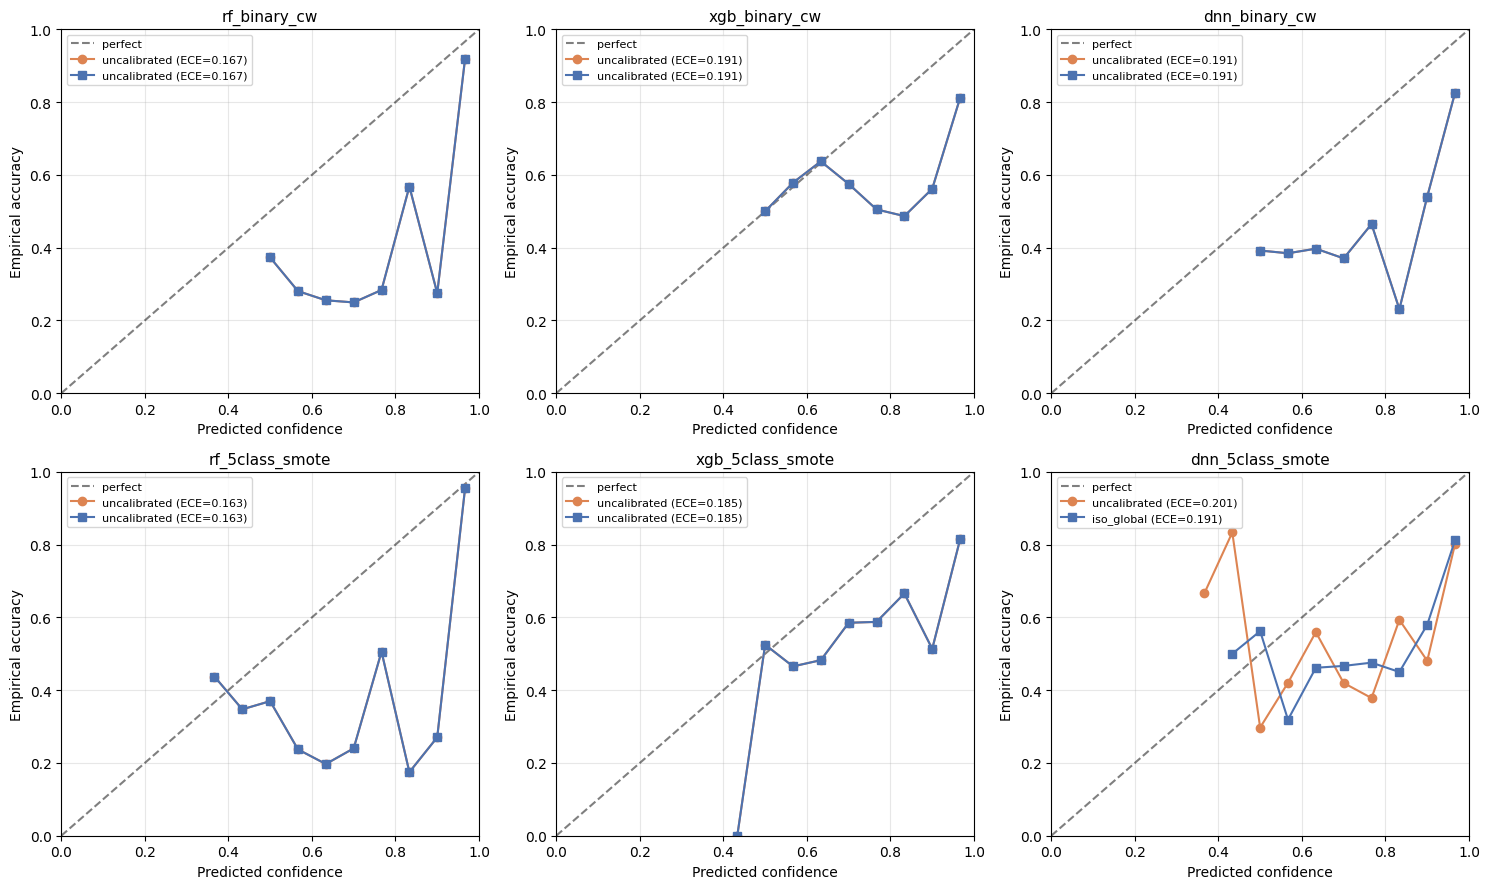

In [12]:
def reliability_data(y_true, y_proba, n_bins=15):
    '''Return per-bin (bin_centre, accuracy, count) for plotting.'''
    confidences = y_proba.max(axis=1)
    predictions = y_proba.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    centres, accs, counts = [], [], []
    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (confidences > lo) & (confidences <= hi)
        if i == 0:
            in_bin = in_bin | (confidences == lo)
        if in_bin.sum() > 0:
            centres.append((lo + hi) / 2)
            accs.append(accuracies[in_bin].mean())
            counts.append(in_bin.sum())
        else:
            centres.append((lo + hi) / 2)
            accs.append(np.nan)
            counts.append(0)
    return np.array(centres), np.array(accs), np.array(counts)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, info) in zip(axes.flatten(), CANONICAL.items()):
    y_true = y_test_b if info['target'] == 'binary' else y_test_5

    # Uncalibrated
    c0, a0, _ = reliability_data(y_true, PREDS[name]['proba_test'])
    # Winning calibrated
    winning_variant = WINNERS[name]['variant']
    if winning_variant == 'uncalibrated':
        winning_proba = PREDS[name]['proba_test']
    else:
        winning_proba = PREDS[name][f'proba_test_{winning_variant}']
    c1, a1, _ = reliability_data(y_true, winning_proba)

    # Plot
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
    ax.plot(c0, a0, 'o-', color='#DD8452', label=f'uncalibrated (ECE={BASELINE[name]["ece"]:.3f})')
    ax.plot(c1, a1, 's-', color='#4C72B0', label=f'{winning_variant} (ECE={WINNERS[name]["ece"]:.3f})')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted confidence'); ax.set_ylabel('Empirical accuracy')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nslkdd_reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Commit

In [13]:
os.chdir(REPO)
!git add notebooks/03_calibration.ipynb
!git add results/
!git status --short
!git commit -m 'Notebook 03: per-class temperature scaling + isotonic regression calibration'
!git push

fatal: pathspec 'notebooks/03_calibration.ipynb' did not match any files
 M notebooks/02b_rare_class_boost.ipynb
A  results/figures/nslkdd_reliability_diagrams.png
A  results/tables/nslkdd_calibration_comparison.csv
?? calibrators/
?? models/
[main b72c880] Notebook 03: per-class temperature scaling + isotonic regression calibration
 2 files changed, 31 insertions(+)
 create mode 100644 results/figures/nslkdd_reliability_diagrams.png
 create mode 100644 results/tables/nslkdd_calibration_comparison.csv
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 211.83 KiB | 6.83 MiB/s, done.
Total 7 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/anasbiswas1/xids-research.git
   095c0eb..b72c880  main -> main


In [ ]:
import os, shutil, subprocess

REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'

# Find Notebook 03 wherever Colab put it
result = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', '03_calibration.ipynb', '-type', 'f'],
    capture_output=True, text=True
)
print("Found at:")
print(result.stdout)

# Move it to the right place
nb_target = f'{REPO}/notebooks/03_calibration.ipynb'
for line in result.stdout.strip().split('\n'):
    if line and line != nb_target and os.path.exists(line):
        shutil.move(line, nb_target)
        print(f"✓ Moved to: {nb_target}")
        break
else:
    if os.path.exists(nb_target):
        print(f"✓ Already in place")

# Commit
os.chdir(REPO)
!git add notebooks/03_calibration.ipynb
!git commit -m "Add Notebook 03 file (calibration)"
!git push

---
## Summary

**What this notebook produced:**
- ✓ 24 fitted calibrators (6 models × 4 variants)
- ✓ 6 winning calibrated probability arrays (one per canonical model)
- ✓ Full comparison table (uncalibrated baseline + 4 calibration variants × 6 models = 30 rows)
- ✓ Reliability diagrams for the paper
- ✓ ECE reductions documented per model

**What to look at in the output:**
- Baseline ECE values — most likely 0.05–0.20 (DNNs tend to be most miscalibrated, trees less so)
- The per-model winner — typically `iso_perclass` wins on imbalanced multi-class, `temp_perclass` wins on binary
- Reliability diagrams — the calibrated line should hug the diagonal more closely

**Next notebook (04):** Compute SHAP values for all 6 calibrated models. TreeSHAP for RF + XGBoost (fast, exact), DeepSHAP for DNN. Save SHAP arrays for stability tests (Notebook 05) and cross-model agreement (Notebook 06).
